# 04 - Comparación SVM-RBF y QSVM

Ejecutamos una comparación pequeña con las mismas 16 muestras para ambos modelos.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'main.py').exists())
sys.path.insert(0, str(ROOT))
from prepare_data import load_data
from quantum_model import compare_models

X_train, X_test, y_train, y_test = load_data(ROOT / 'data/raw/water_potability.csv')
results = compare_models(
    X_train, X_test, y_train, y_test,
    feature_map='custom', subset_sizes=[16], repeats=1,
    cv_folds=2, seed=20260802, circuit_repetitions=2,
)
results

,model,subset_size,repeat,accuracy,balanced_accuracy,precision,recall,f1,false_positive_rate
0,QSVM,16,0,0.528963,0.518828,0.410169,0.472656,0.439201,0.435
1,SVM-RBF,16,0,0.510671,0.503828,0.394137,0.472656,0.429840,0.465


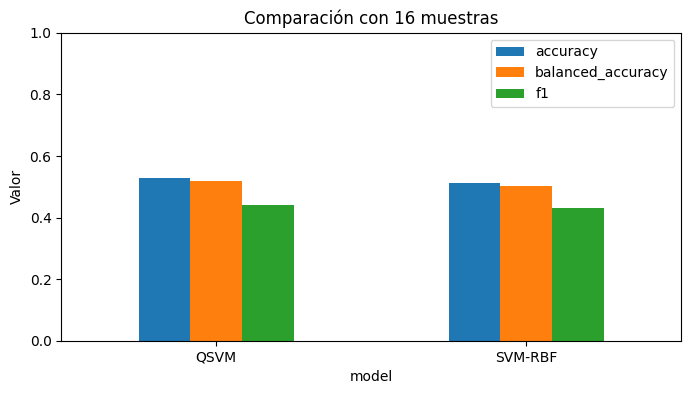

In [2]:
results.set_index('model')[['accuracy', 'balanced_accuracy', 'f1']].plot.bar(figsize=(8, 4))
plt.ylim(0, 1)
plt.ylabel('Valor')
plt.title('Comparación con 16 muestras')
plt.xticks(rotation=0)
plt.show()

Para los resultados finales se ejecutan los tamaños 16, 32 y 64 con cinco repeticiones usando `python main.py`.